# Fine-tuning — Adaptive Training with Deep Error Analysis bich

This notebook picks up from the best checkpoint produced by `training.ipynb` and runs:

1. **Deep Error Analysis** — per-class MAE, confusion matrix, worst-offender pairs.
2. **Adaptive Fine-tuning** — a dynamic training loop that monitors live metrics and
   auto-adjusts learning rate, augmentation strength, label smoothing, and class
   weights each epoch based on what the model is actually struggling with.

### Prerequisites
- Shared Google Drive folder (same `DRIVE_FOLDER_ID` as `training.ipynb`).
- `best.pth` must exist in the `checkpoints/` sub-folder (produced by initial training).

Checkpoints are saved back to the same Drive folder as `finetune_latest.pth` / `finetune_best.pth`
so any account can resume.

---

In [ ]:
import zipfile, os, io, torch, logging as _logging

# ── Configuration ────────────────────────────────────────────────────────────
DRIVE_FOLDER_ID = "1GwLV_ZFaeSw0w59OU1ToCGuG5EkHgk5f"
LOCAL_EXTRACT   = "/content/dataset"
CHECKPOINT_DIR  = "/content/checkpoints"

COLOR_CLASSES = [
    "red", "orange", "yellow", "green", "blue",
    "violet", "purple", "white", "gray", "black",
    "pink", "brown", "olive",
]
NUM_CLASSES = len(COLOR_CLASSES)

# ── Authenticate ─────────────────────────────────────────────────────────────
from google.colab import auth as _colab_auth
_colab_auth.authenticate_user()

import subprocess
subprocess.run(["pip", "install", "-q", "gdown"], check=True)
import gdown
from googleapiclient.discovery import build as _build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload

_drive = _build("drive", "v3")
_logging.getLogger("google_auth_httplib2").setLevel(_logging.ERROR)

def _list_folder(folder_id):
    items, page_token = [], None
    while True:
        resp = _drive.files().list(
            q=f"'{folder_id}' in parents and trashed=false",
            fields="nextPageToken, files(id,name,mimeType)",
            pageToken=page_token,
        ).execute()
        items.extend(resp.get("files", []))
        page_token = resp.get("nextPageToken")
        if not page_token:
            break
    return items

def _download_file(file_id, local_path):
    request = _drive.files().get_media(fileId=file_id)
    with open(local_path, "wb") as fh:
        dl = MediaIoBaseDownload(fh, request)
        done = False
        while not done:
            _, done = dl.next_chunk()

# ── Locate checkpoints folder ────────────────────────────────────────────────
_folder_contents = _list_folder(DRIVE_FOLDER_ID)
_ckpt_folder_entry = next(
    (f for f in _folder_contents
     if f["name"] == "checkpoints"
     and f["mimeType"] == "application/vnd.google-apps.folder"),
    None,
)
if _ckpt_folder_entry is None:
    raise FileNotFoundError("No 'checkpoints' folder found in Drive — run training.ipynb first.")

DRIVE_CKPT_FOLDER_ID = _ckpt_folder_entry["id"]
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Download all checkpoint files
_drive_ckpt_files = {f["name"]: f["id"] for f in _list_folder(DRIVE_CKPT_FOLDER_ID)}
for _name, _fid in _drive_ckpt_files.items():
    _local = os.path.join(CHECKPOINT_DIR, _name)
    print(f"Downloading: {_name} ...")
    _download_file(_fid, _local)
print("Checkpoints ready.")

# ── Download & extract dataset ────────────────────────────────────────────────
def _find_file(root, name):
    for dirpath, _, filenames in os.walk(root):
        if name in filenames:
            return os.path.join(dirpath, name)
    return None

csv_found = _find_file(LOCAL_EXTRACT, "labels.csv") if os.path.exists(LOCAL_EXTRACT) else None
if csv_found is None:
    _zip_entry = next((f for f in _folder_contents if f["name"].endswith(".zip")), None)
    if _zip_entry is None:
        raise FileNotFoundError("No .zip file found in Drive folder!")
    print(f"Downloading dataset: {_zip_entry['name']} ...")
    zip_path = "/content/generated_dataset.zip"
    gdown.download(id=_zip_entry["id"], output=zip_path, quiet=False)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(LOCAL_EXTRACT)
    os.remove(zip_path)
    csv_found = _find_file(LOCAL_EXTRACT, "labels.csv")
    if csv_found is None:
        raise FileNotFoundError("labels.csv not found inside the zip!")
    print("Done.")
else:
    print("Dataset already extracted.")

CSV_PATH = csv_found
IMG_DIR  = os.path.join(os.path.dirname(csv_found), "images")
print(f"CSV : {CSV_PATH}")
print(f"Imgs: {IMG_DIR}  ({len(os.listdir(IMG_DIR))} files)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))

Downloading: latest.pth ...
Downloading: best.pth ...
Checkpoints ready.


Downloading...
From (original): https://drive.google.com/uc?id=16qa5Z4LNw_zZB9zTN7oTRcnyPxh-Wt8r
From (redirected): https://drive.google.com/uc?id=16qa5Z4LNw_zZB9zTN7oTRcnyPxh-Wt8r&confirm=t&uuid=e151e789-9927-4bed-9930-35b99cf4e40a
To: /content/generated_dataset.zip
100%|██████████| 501M/501M [00:03<00:00, 162MB/s]


Done.
CSV : /content/dataset/generated/labels.csv
Imgs: /content/dataset/generated/images  (22000 files)
Device: cuda (Tesla T4)


## Dataset & Model

In [ ]:
import random
import pandas as pd
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF
import PIL.Image


class ColorDataset(Dataset):
    def __init__(self, csv_path, img_dir, split, color_classes, transform=None):
        df = pd.read_csv(csv_path)
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.img_dir = img_dir
        self.color_classes = color_classes
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(os.path.join(self.img_dir, row["filename"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        label = torch.tensor([row[c] for c in self.color_classes], dtype=torch.float32)
        return img, label


class RandomColorTemperature:
    def __init__(self, strength=0.3):
        self.strength = strength

    def __call__(self, img):
        arr = np.array(img, dtype=np.float32)
        t = random.uniform(-self.strength, self.strength)
        arr[:, :, 0] = np.clip(arr[:, :, 0] * (1.0 + t), 0, 255)
        arr[:, :, 2] = np.clip(arr[:, :, 2] * (1.0 - t), 0, 255)
        return PIL.Image.fromarray(arr.astype(np.uint8))


def create_model(num_classes=13, dropout=0.4):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes),
    )
    return model


def build_transforms(color_jitter_strength=0.6, temp_strength=0.3, erasing_prob=0.5):
    """Build train/val transforms with tuneable augmentation knobs."""
    train_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(),
        transforms.Lambda(lambda img: TF.rotate(img, random.choice([0, 90, 180, 270]))),
        transforms.ColorJitter(
            brightness=color_jitter_strength,
            contrast=color_jitter_strength,
            saturation=color_jitter_strength,
            hue=0.07,
        ),
        RandomColorTemperature(strength=temp_strength),
        transforms.ToTensor(),
        transforms.RandomErasing(p=erasing_prob, scale=(0.02, 0.25), ratio=(0.3, 3.3)),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return train_tf, val_tf


# ── Load best checkpoint ─────────────────────────────────────────────────────
FRESH_START = True   # True = ignore old finetune checkpoints, restart from best.pth

ft_best_path = os.path.join(CHECKPOINT_DIR, "finetune_best.pth")
ft_latest_path = os.path.join(CHECKPOINT_DIR, "finetune_latest.pth")
orig_best_path = os.path.join(CHECKPOINT_DIR, "best.pth")

if not FRESH_START and os.path.exists(ft_latest_path):
    _init_ckpt_path = ft_latest_path
    print(f"Resuming from finetune checkpoint: {_init_ckpt_path}")
elif os.path.exists(orig_best_path):
    _init_ckpt_path = orig_best_path
    print(f"Starting fine-tune from initial-training best: {_init_ckpt_path}")
else:
    raise FileNotFoundError("No checkpoint found — run training.ipynb first.")

model = create_model(num_classes=NUM_CLASSES, dropout=0.4).to(device)
_ckpt = torch.load(_init_ckpt_path, map_location=device)
model.load_state_dict(_ckpt["model_state_dict"])
print(f"Loaded weights from epoch {_ckpt['epoch'] + 1}, val loss {_ckpt['best_val_loss']:.4f}")

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 64
train_tf, val_tf = build_transforms()

train_ds = ColorDataset(CSV_PATH, IMG_DIR, "train", COLOR_CLASSES, train_tf)
val_ds   = ColorDataset(CSV_PATH, IMG_DIR, "val",   COLOR_CLASSES, val_tf)
test_ds  = ColorDataset(CSV_PATH, IMG_DIR, "test",  COLOR_CLASSES, val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# test_loader only if test split exists; otherwise post-analysis will use val
if len(test_ds) > 0:
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
else:
    test_loader = val_loader
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: (no test split — will use val)")

Starting fine-tune from initial-training best: /content/checkpoints/best.pth
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 102MB/s]


Loaded weights from epoch 25, val loss 0.7474
Train: 20000 | Val: 2000 | Test: (no test split — will use val)


## 1. Deep Error Analysis

Before touching the training loop, let's understand *where* the model fails.

- **Per-class MAE** — which colors have the highest prediction error?
- **Confusion matrix** — which color *pairs* does the model confuse?
- **Worst samples** — what do the highest-error images look like?

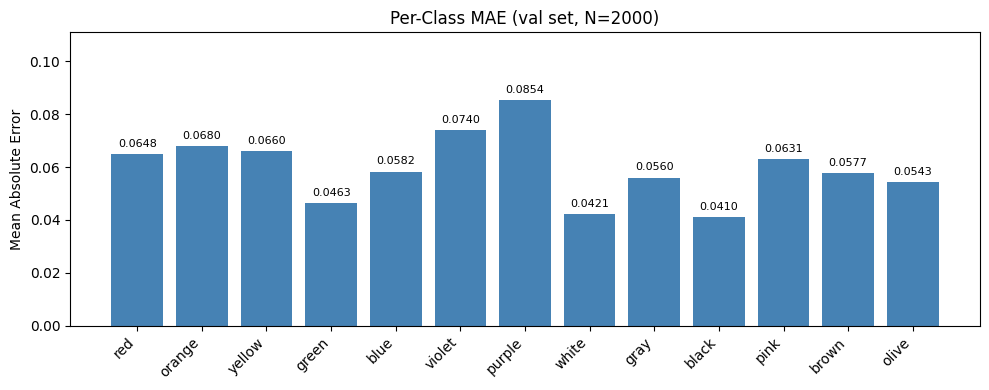

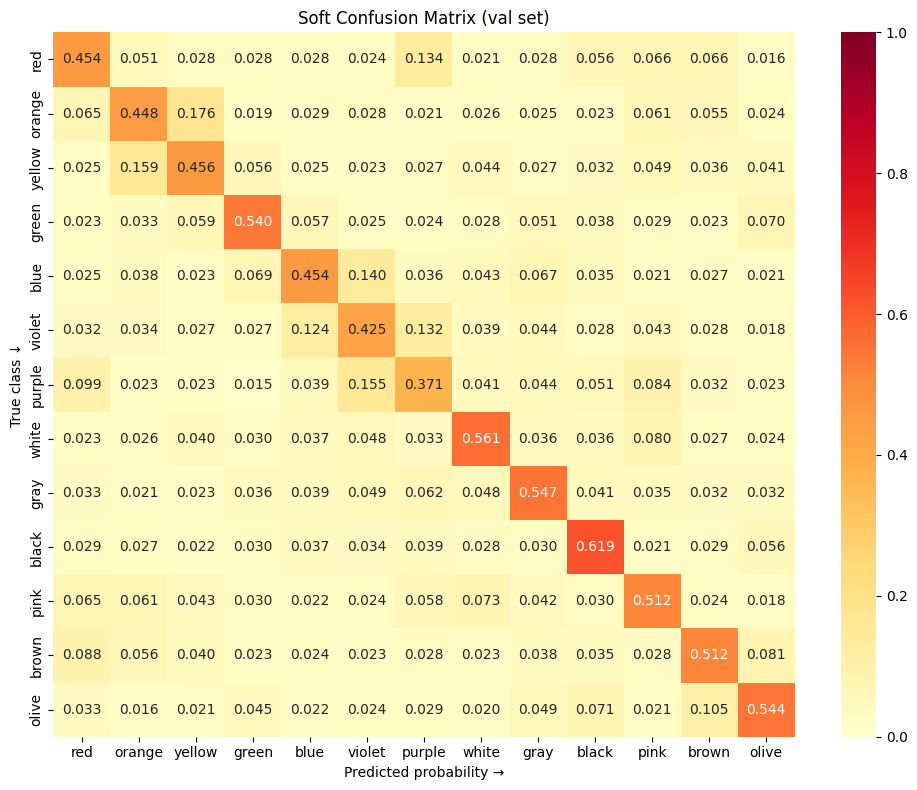


Top 10 confused pairs (true → predicted, avg probability):
    orange → yellow    0.1763
    yellow → orange    0.1590
    purple → violet    0.1546
      blue → violet    0.1396
       red → purple    0.1341
    violet → purple    0.1318
    violet → blue      0.1238
     olive → brown     0.1049
    purple → red       0.0991
     brown → red       0.0883


In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns


def run_error_analysis(model, loader, color_classes, device, label="val"):
    """Compute per-class MAE + soft confusion matrix on a DataLoader."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            probs = F.softmax(model(imgs), dim=1).cpu()
            all_preds.append(probs)
            all_labels.append(labels)

    preds  = torch.cat(all_preds,  dim=0)   # (N, C)
    labels = torch.cat(all_labels, dim=0)   # (N, C)
    errors = (preds - labels).abs()          # (N, C)
    N, C = preds.shape

    # ── Per-class MAE ────────────────────────────────────────────────────────
    per_class_mae = errors.mean(dim=0).numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(color_classes, per_class_mae, color="steelblue")
    ax.set_ylabel("Mean Absolute Error")
    ax.set_title(f"Per-Class MAE ({label} set, N={N})")
    ax.set_ylim(0, max(per_class_mae) * 1.3)
    for bar, val in zip(bars, per_class_mae):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # ── Soft confusion matrix ────────────────────────────────────────────────
    # For each sample, take argmax of the true label as the "intended" class.
    # Then accumulate the predicted probability mass into a C×C matrix.
    true_cls = labels.argmax(dim=1)   # (N,)
    confusion = torch.zeros(C, C)
    for c in range(C):
        mask = true_cls == c
        if mask.sum() == 0:
            continue
        confusion[c] = preds[mask].mean(dim=0)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion.numpy(), annot=True, fmt=".3f", cmap="YlOrRd",
        xticklabels=color_classes, yticklabels=color_classes, ax=ax,
        vmin=0, vmax=1,
    )
    ax.set_xlabel("Predicted probability →")
    ax.set_ylabel("True class ↓")
    ax.set_title(f"Soft Confusion Matrix ({label} set)")
    plt.tight_layout()
    plt.show()

    # ── Top confused pairs ───────────────────────────────────────────────────
    # Off-diagonal entries where true != predicted
    off_diag = []
    for i in range(C):
        for j in range(C):
            if i != j:
                off_diag.append((color_classes[i], color_classes[j], confusion[i, j].item()))
    off_diag.sort(key=lambda x: -x[2])

    print("\nTop 10 confused pairs (true → predicted, avg probability):")
    for true_c, pred_c, val in off_diag[:10]:
        print(f"  {true_c:>8s} → {pred_c:<8s}  {val:.4f}")

    return per_class_mae, confusion


per_class_mae, confusion = run_error_analysis(model, val_loader, COLOR_CLASSES, device, "val")

## 2. Adaptive Fine-tuning Loop

This loop **recalibrates every epoch** based on validation metrics:

| Signal | What it controls |
|---|---|
| Per-class val MAE | **Class weights** — classes with higher error get proportionally higher weight (soft-label aware: `weight = Σ(label_i × class_weight_i)`) |
| Val loss trend (epoch-over-epoch) | **Augmentation strength** — val loss increasing → more augmentation; decreasing → ease off |
| Val loss vs best + stagnation count | **Label smoothing** — increases when stagnating (no improve for 2+ epochs), decreases when improving |

Key design choices:
- **Discriminative learning rates** instead of progressive unfreezing — head gets full LR, deeper layers get 10–1000× smaller LRs. No optimizer restarts, no momentum loss.
- **Proportional class weighting** for soft labels — distributes weight across all colors in a sample, not just argmax.
- Val predictions captured during the validation pass and reused for adaptation — no redundant forward pass.
- Augmentation and smoothing signals use **val loss trend** (directional), not the train-val gap (which compared different loss functions).

In [ ]:
import threading, queue as _queue_mod
import torch.nn.functional as F
from tqdm.notebook import tqdm
from googleapiclient.http import MediaFileUpload

# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
FT_MAX_EPOCHS    = 60
FT_EARLY_STOP    = 12
FT_INITIAL_LR    = 3e-5
FT_WEIGHT_DECAY  = 1e-2

LABEL_SMOOTH_MIN = 0.02
LABEL_SMOOTH_MAX = 0.15
AUG_STRENGTH_MIN = 0.3
AUG_STRENGTH_MAX = 0.8

# ══════════════════════════════════════════════════════════════════════════════
#  DISCRIMINATIVE LEARNING RATES
# ══════════════════════════════════════════════════════════════════════════════
def get_param_groups(model, base_lr, weight_decay):
    """All layers trainable with decreasing LRs — no freeze/unfreeze needed."""
    buckets = {
        "backbone_early": {"params": [], "lr": base_lr * 0.001},
        "layer3":         {"params": [], "lr": base_lr * 0.01},
        "layer4":         {"params": [], "lr": base_lr * 0.1},
        "fc":             {"params": [], "lr": base_lr},
    }
    for name, p in model.named_parameters():
        p.requires_grad = True
        if "fc" in name:
            buckets["fc"]["params"].append(p)
        elif name.startswith("layer4"):
            buckets["layer4"]["params"].append(p)
        elif name.startswith("layer3"):
            buckets["layer3"]["params"].append(p)
        else:
            buckets["backbone_early"]["params"].append(p)

    groups = []
    for bname, b in buckets.items():
        groups.append({"params": b["params"], "lr": b["lr"], "weight_decay": weight_decay})
        n = sum(p.numel() for p in b["params"])
        print(f"  {bname:>16s}: {n:>12,} params, lr={b['lr']:.1e}")
    n_total = sum(p.numel() for p in model.parameters())
    print(f"  {'TOTAL':>16s}: {n_total:>12,} params (all trainable)")
    return groups

# ══════════════════════════════════════════════════════════════════════════════
#  ADAPTIVE STATE
# ══════════════════════════════════════════════════════════════════════════════
class AdaptiveState:
    def __init__(self):
        self.label_smooth   = 0.10
        self.aug_strength   = 0.6
        self.class_weights  = torch.ones(NUM_CLASSES, device=device)

    def recalibrate(self, epoch, val_loss, prev_val_loss,
                    best_val_loss, epochs_no_improve,
                    val_preds, val_labels):
        """Adjust knobs using val predictions already captured — no extra forward pass."""
        changes = []

        # ── 1. Class weights from per-class val MAE ──────────────────────────
        mae = (val_preds - val_labels).abs().mean(dim=0)           # (C,)
        raw_w = (mae / mae.mean()).clamp(0.5, 3.0)
        self.class_weights = raw_w.to(device)
        top3 = torch.topk(mae, 3)
        top3_str = ", ".join(f"{COLOR_CLASSES[i]}={mae[i]:.4f}" for i in top3.indices)
        changes.append(f"class weights (worst: {top3_str})")

        # ── 2. Augmentation from val loss trend ──────────────────────────────
        if prev_val_loss is not None:
            val_delta = val_loss - prev_val_loss    # positive = getting worse
            if val_delta > 0.005:
                self.aug_strength = min(AUG_STRENGTH_MAX, self.aug_strength + 0.05)
                changes.append(f"aug ↑ {self.aug_strength:.2f}")
            elif val_delta < -0.005 and self.aug_strength > AUG_STRENGTH_MIN:
                self.aug_strength = max(AUG_STRENGTH_MIN, self.aug_strength - 0.03)
                changes.append(f"aug ↓ {self.aug_strength:.2f}")

        # ── 3. Label smoothing — increase when stagnating, decrease when improving
        if prev_val_loss is not None:
            if val_loss > best_val_loss + 0.02 and epochs_no_improve >= 2:
                self.label_smooth = min(LABEL_SMOOTH_MAX, self.label_smooth + 0.01)
                changes.append(f"smooth ↑ {self.label_smooth:.2f}")
            elif val_loss <= best_val_loss + 0.005:
                self.label_smooth = max(LABEL_SMOOTH_MIN, self.label_smooth - 0.01)
                changes.append(f"smooth ↓ {self.label_smooth:.2f}")

        if changes:
            print(f"  [adapt] {' | '.join(changes)}")


adapt = AdaptiveState()

# ══════════════════════════════════════════════════════════════════════════════
#  OPTIMIZER (discriminative LRs — all layers trainable from the start)
# ══════════════════════════════════════════════════════════════════════════════
param_groups = get_param_groups(model, FT_INITIAL_LR, FT_WEIGHT_DECAY)
optimizer = torch.optim.AdamW(param_groups)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5,
)

start_epoch       = 0
best_val_loss     = float("inf")
epochs_no_improve = 0
ft_train_losses   = []
ft_val_losses     = []

if not FRESH_START and os.path.exists(ft_latest_path) and _init_ckpt_path == ft_latest_path:
    ft_ckpt = torch.load(ft_latest_path, map_location=device)
    start_epoch       = ft_ckpt["epoch"] + 1
    best_val_loss     = ft_ckpt["best_val_loss"]
    epochs_no_improve = 0
    ft_train_losses   = ft_ckpt.get("train_losses", [])
    ft_val_losses     = ft_ckpt.get("val_losses", [])
    _as = ft_ckpt.get("adaptive_state", {})
    adapt.label_smooth  = _as.get("label_smooth", adapt.label_smooth)
    adapt.aug_strength  = _as.get("aug_strength", adapt.aug_strength)
    if "class_weights" in _as:
        adapt.class_weights = torch.tensor(_as["class_weights"], device=device)
    if "optimizer_state_dict" in ft_ckpt:
        try:
            optimizer.load_state_dict(ft_ckpt["optimizer_state_dict"])
        except (ValueError, KeyError):
            print("  Optimizer state incompatible — starting fresh optimizer.")
    if "scheduler_state_dict" in ft_ckpt:
        try:
            scheduler.load_state_dict(ft_ckpt["scheduler_state_dict"])
        except (ValueError, KeyError):
            pass
    print(f"Resumed fine-tune from epoch {start_epoch}, best val loss: {best_val_loss:.4f}")
else:
    print("Starting fresh fine-tune (all layers, discriminative LRs).")

# ══════════════════════════════════════════════════════════════════════════════
#  DRIVE UPLOAD WORKER
# ══════════════════════════════════════════════════════════════════════════════
_ft_drive_ckpt_file_ids = dict(_drive_ckpt_files)
_ft_drive_lock = threading.Lock()
_ft_upload_queue = _queue_mod.Queue()

def _to_cpu(obj):
    if isinstance(obj, torch.Tensor):
        return obj.cpu().clone()
    if isinstance(obj, dict):
        return {k: _to_cpu(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_cpu(x) for x in obj]
    return obj

def _ft_upload_worker():
    import google.auth, logging
    from googleapiclient.discovery import build as _build_svc
    logging.getLogger("google_auth_httplib2").setLevel(logging.ERROR)
    creds, _ = google.auth.default()
    drive_svc = _build_svc("drive", "v3", credentials=creds)
    while True:
        task = _ft_upload_queue.get()
        if task is None:
            _ft_upload_queue.task_done()
            break
        state, path = task
        filename = os.path.basename(path)
        try:
            os.makedirs(os.path.dirname(path), exist_ok=True)
            torch.save(state, path)
            media = MediaFileUpload(path, resumable=True)
            with _ft_drive_lock:
                existing_id = _ft_drive_ckpt_file_ids.get(filename)
            if existing_id:
                drive_svc.files().update(
                    fileId=existing_id, media_body=media,
                ).execute(num_retries=5)
            else:
                created = drive_svc.files().create(
                    body={"name": filename, "parents": [DRIVE_CKPT_FOLDER_ID]},
                    media_body=media, fields="id",
                ).execute(num_retries=5)
                with _ft_drive_lock:
                    _ft_drive_ckpt_file_ids[filename] = created["id"]
            print(f"  [Drive] saved {filename}")
        except Exception as exc:
            print(f"  [Drive] WARNING: {filename}: {exc}")
        finally:
            _ft_upload_queue.task_done()

_ft_worker = threading.Thread(target=_ft_upload_worker, name="FT-DriveUploader", daemon=True)
_ft_worker.start()

# ══════════════════════════════════════════════════════════════════════════════
#  ADAPTIVE TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════════════
criterion = nn.KLDivLoss(reduction="none")   # per-sample so we can apply class weights
prev_val_loss     = None
prev_aug_strength = adapt.aug_strength

for epoch in range(start_epoch, FT_MAX_EPOCHS):
    # ── Rebuild DataLoader if augmentation changed ────────────────────────
    if adapt.aug_strength != prev_aug_strength:
        train_tf, _ = build_transforms(
            color_jitter_strength=adapt.aug_strength,
            temp_strength=adapt.aug_strength * 0.5,
            erasing_prob=0.3 + adapt.aug_strength * 0.3,
        )
        train_ds = ColorDataset(CSV_PATH, IMG_DIR, "train", COLOR_CLASSES, train_tf)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=2, pin_memory=True)
        prev_aug_strength = adapt.aug_strength

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    running = 0.0
    uniform = 1.0 / NUM_CLASSES
    for imgs, labels in tqdm(train_loader, desc=f"FT {epoch+1}/{FT_MAX_EPOCHS} [train]", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        # Dynamic label smoothing
        labels = (1 - adapt.label_smooth) * labels + adapt.label_smooth * uniform
        optimizer.zero_grad()
        log_probs = F.log_softmax(model(imgs), dim=1)
        # Proportional class weighting: weight each sample by its soft label distribution
        per_sample = criterion(log_probs, labels).sum(dim=1)                  # (B,)
        weights = (labels * adapt.class_weights.unsqueeze(0)).sum(dim=1)      # (B,)
        loss = (per_sample * weights).mean()
        loss.backward()
        optimizer.step()
        running += loss.item() * imgs.size(0)
    train_loss = running / len(train_ds)

    # ── Validate (capture predictions for reuse in recalibrate) ──────────
    model.eval()
    running = 0.0
    all_val_preds, all_val_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            log_probs = F.log_softmax(model(imgs), dim=1)
            running += F.kl_div(log_probs, labels, reduction="batchmean").item() * imgs.size(0)
            all_val_preds.append(log_probs.exp().cpu())
            all_val_labels.append(labels.cpu())
    val_loss = running / len(val_ds)
    val_preds  = torch.cat(all_val_preds)
    val_labels = torch.cat(all_val_labels)

    scheduler.step(val_loss)
    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)

    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    lr_fc = optimizer.param_groups[-1]["lr"]   # fc group is last
    marker = " !" if is_best else ""
    print(f"FT {epoch+1:>2}/{FT_MAX_EPOCHS} | train: {train_loss:.4f} | val: {val_loss:.4f}"
          f" | lr(fc): {lr_fc:.1e} | no-improve: {epochs_no_improve}"
          f" | smooth: {adapt.label_smooth:.2f} | aug: {adapt.aug_strength:.2f}{marker}")

    # ── Adapt for next epoch ─────────────────────────────────────────────────
    adapt.recalibrate(
        epoch, val_loss, prev_val_loss,
        best_val_loss, epochs_no_improve,
        val_preds, val_labels,
    )
    prev_val_loss = val_loss

    # ── Save checkpoint ──────────────────────────────────────────────────────
    _ft_upload_queue.join()

    ckpt_data = {
        "epoch": epoch,
        "model_state_dict": _to_cpu(model.state_dict()),
        "optimizer_state_dict": _to_cpu(optimizer.state_dict()),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "epochs_no_improve": epochs_no_improve,
        "train_losses": ft_train_losses.copy(),
        "val_losses": ft_val_losses.copy(),
        "adaptive_state": {
            "label_smooth": adapt.label_smooth,
            "aug_strength": adapt.aug_strength,
            "class_weights": adapt.class_weights.cpu().tolist(),
        },
    }
    _ft_upload_queue.put((ckpt_data, ft_latest_path))
    if is_best:
        _ft_upload_queue.put((ckpt_data, ft_best_path))

    # ── Early stopping ───────────────────────────────────────────────────────
    if epochs_no_improve >= FT_EARLY_STOP:
        print(f"\nEarly stopping at FT epoch {epoch+1} (no improvement for {FT_EARLY_STOP} epochs).")
        break

# Clean up
_ft_upload_queue.join()
_ft_upload_queue.put(None)
_ft_worker.join()
print(f"\nFine-tuning complete. Best val loss: {best_val_loss:.4f}")

  Unfreeze stage 0: 26,637/23,534,669 params trainable
Starting fresh fine-tune (head only).


FT 1/60 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

FT  1/60 | train: 0.5184 | val: 0.7475 | lr: 3.0e-05 | no-improve: 0 | smooth: 0.10 | aug: 0.60 !
  [adapt] class weights updated (worst: purple=0.0846, violet=0.0745, orange=0.0678) | smooth ↑ 0.12


FT 2/60 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Drive] saved finetune_latest.pth
  [Drive] saved finetune_best.pth
FT  2/60 | train: 0.5149 | val: 0.7534 | lr: 3.0e-05 | no-improve: 1 | smooth: 0.12 | aug: 0.60
  [adapt] class weights updated (worst: purple=0.0884, violet=0.0762, orange=0.0678) | aug ↓ 0.55 | smooth ↑ 0.14


...

  [Drive] saved finetune_latest.pth
FT 13/60 | train: 0.2765 | val: 0.8107 | lr: 3.0e-05 | no-improve: 10 | smooth: 0.20 | aug: 0.30
  [adapt] class weights updated (worst: purple=0.0884, violet=0.0821, orange=0.0759) | aug ↓ 0.30 | smooth ↑ 0.20


FT 14/60 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Drive] saved finetune_latest.pth
FT 14/60 | train: 0.2647 | val: 0.7988 | lr: 1.5e-05 | no-improve: 11 | smooth: 0.20 | aug: 0.30
  [adapt] class weights updated (worst: purple=0.0876, violet=0.0802, orange=0.0720) | smooth ↑ 0.20


FT 15/60 [train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Drive] saved finetune_latest.pth
FT 15/60 | train: 0.2522 | val: 0.8104 | lr: 1.5e-05 | no-improve: 12 | smooth: 0.20 | aug: 0.30
  [adapt] class weights updated (worst: purple=0.0908, violet=0.0828, orange=0.0737) | aug ↓ 0.30 | smooth ↑ 0.20

Early stopping at FT epoch 15 (no improvement for 12 epochs).
  [Drive] saved finetune_latest.pth

Fine-tuning complete. Best val loss: 0.7469


## Training Curves

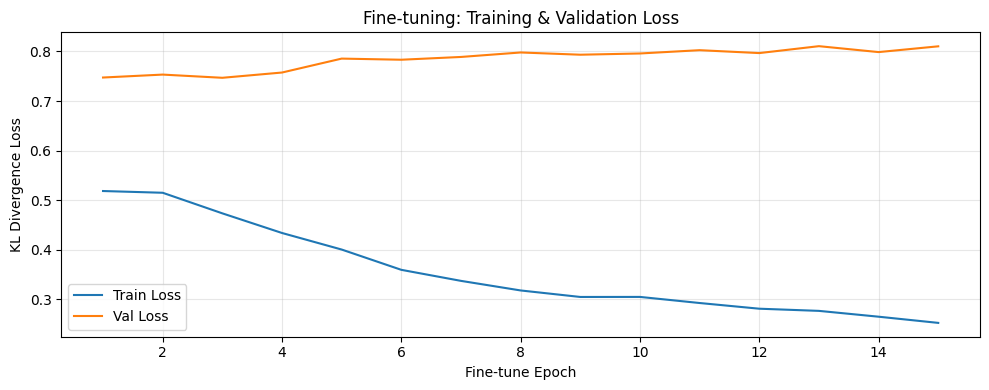

Best val loss: 0.7469 at FT epoch 3


In [ ]:
import matplotlib.pyplot as plt

if not ft_train_losses:
    ckpt = torch.load(ft_latest_path, map_location="cpu")
    ft_train_losses = ckpt.get("train_losses", [])
    ft_val_losses   = ckpt.get("val_losses", [])

epochs_range = range(1, len(ft_train_losses) + 1)

plt.figure(figsize=(10, 4))
plt.plot(epochs_range, ft_train_losses, label="Train Loss")
plt.plot(epochs_range, ft_val_losses,   label="Val Loss")
plt.xlabel("Fine-tune Epoch")
plt.ylabel("KL Divergence Loss")
plt.title("Fine-tuning: Training & Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best val loss: {min(ft_val_losses):.4f} at FT epoch {ft_val_losses.index(min(ft_val_losses)) + 1}")

## Post-Finetuning Error Analysis

Re-run the same analysis on the **test** set to compare before/after.

Loaded finetune_best.pth (epoch 3, val loss 0.7469)

── Val Set Analysis ──


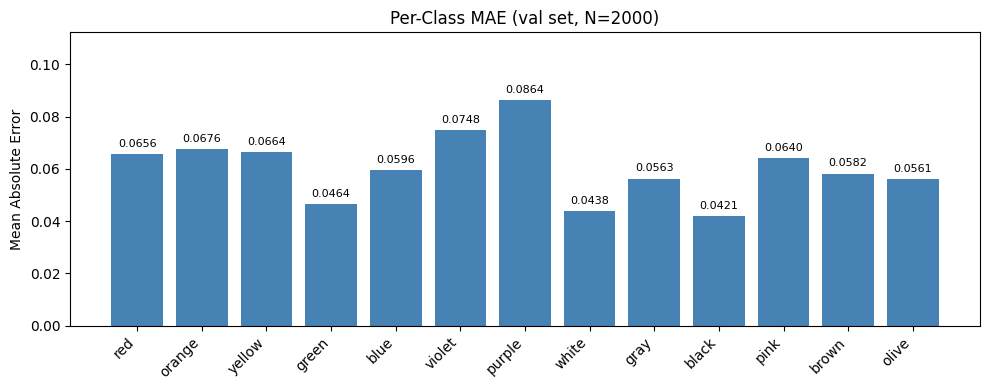

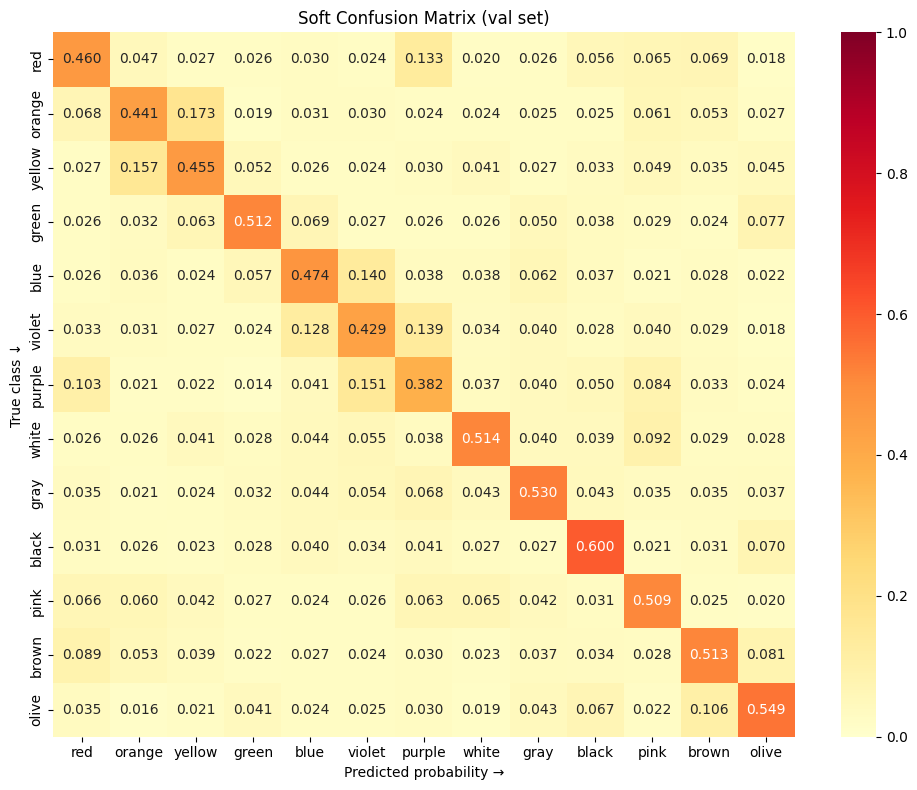


Top 10 confused pairs (true → predicted, avg probability):
    orange → yellow    0.1731
    yellow → orange    0.1575
    purple → violet    0.1512
      blue → violet    0.1397
    violet → purple    0.1386
       red → purple    0.1328
    violet → blue      0.1276
     olive → brown     0.1063
    purple → red       0.1025
     white → pink      0.0920


(array([0.0655664 , 0.06756186, 0.0663773 , 0.04643714, 0.05963809,
        0.07480361, 0.08637628, 0.04375129, 0.05629512, 0.04205055,
        0.06403656, 0.05818552, 0.05607535], dtype=float32),
 tensor([[0.4598, 0.0472, 0.0267, 0.0256, 0.0299, 0.0242, 0.1328, 0.0201, 0.0265,
          0.0556, 0.0650, 0.0687, 0.0179],
         [0.0677, 0.4406, 0.1731, 0.0188, 0.0309, 0.0301, 0.0235, 0.0244, 0.0252,
          0.0254, 0.0607, 0.0531, 0.0265],
         [0.0268, 0.1575, 0.4550, 0.0516, 0.0265, 0.0239, 0.0301, 0.0407, 0.0270,
          0.0325, 0.0486, 0.0353, 0.0446],
         [0.0257, 0.0320, 0.0629, 0.5123, 0.0692, 0.0270, 0.0265, 0.0260, 0.0501,
          0.0383, 0.0291, 0.0237, 0.0773],
         [0.0259, 0.0355, 0.0236, 0.0568, 0.4742, 0.1397, 0.0379, 0.0377, 0.0615,
          0.0367, 0.0206, 0.0278, 0.0221],
         [0.0329, 0.0311, 0.0269, 0.0244, 0.1276, 0.4287, 0.1386, 0.0336, 0.0402,
          0.0282, 0.0404, 0.0289, 0.0185],
         [0.1025, 0.0207, 0.0219, 0.0137, 0.0408, 0.1

In [ ]:
# Load the best finetuned model
if os.path.exists(ft_best_path):
    ft_best = torch.load(ft_best_path, map_location=device)
    model.load_state_dict(ft_best["model_state_dict"])
    print(f"Loaded finetune_best.pth (epoch {ft_best['epoch'] + 1}, val loss {ft_best['best_val_loss']:.4f})")
else:
    print("No finetune_best.pth found — using model from end of training loop.")

_eval_label = "test" if len(test_ds) > 0 else "val"
print(f"\n── {_eval_label.title()} Set Analysis ──")
run_error_analysis(model, test_loader, COLOR_CLASSES, device, _eval_label)